In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 2. Load Dataset
file_path = "/kaggle/input/datasets/zaranisar/housing-price-prediction/housing.csv"
df = pd.read_csv(file_path)
# Standardize column names
df.columns = df.columns.str.lower().str.strip()
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# 3. Check Missing Values
print(df.isnull().sum())
# Fill numeric missing values
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [4]:
# 4. Separate Features and Target
target_col = "median_house_value"

X = df.drop(target_col, axis=1)
y = df[target_col]
print("Features:", X.columns)
print("Target sample:", y.head())

Features: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity'],
      dtype='object')
Target sample: 0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64


In [5]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# 6. Identify numeric & categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [7]:
# 7. Build Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [8]:
# 8. Build Models with Pipeline
# Linear Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])

In [9]:
# 9. Train Models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [10]:
# 10. Make Predictions
y_lr_pred = lr_pipeline.predict(X_test)
y_rf_pred = rf_pipeline.predict(X_test)

In [11]:
# 11. Evaluation Function
def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name} Evaluation:")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

In [12]:
# 12. Evaluate Both Models
evaluate(y_test, y_lr_pred, "Linear Regression")
evaluate(y_test, y_rf_pred, "Random Forest")


Linear Regression Evaluation:
MAE : 50670.73824097188
RMSE: 70060.5218447352
R2 Score: 0.6254240620553604

Random Forest Evaluation:
MAE : 31471.32531976744
RMSE: 48809.923814791204
R2 Score: 0.8181935027640088


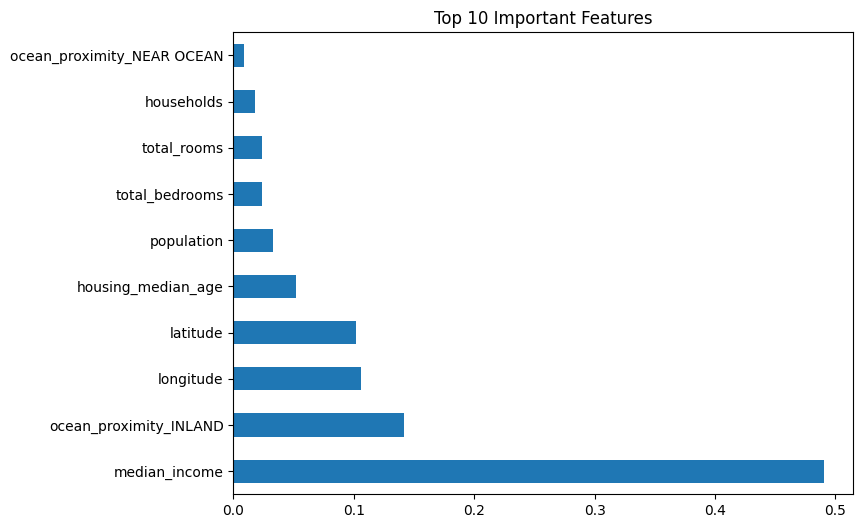

In [13]:
# 13. Feature Importance for Random Forest
rf_model = rf_pipeline.named_steps['regressor']
# Get preprocessed feature names
ohe_features = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'] \
    .named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = numeric_features + list(ohe_features)
importance = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

In [14]:
# 14. Predict Example House
sample_house = X_test.iloc[0:1]
predicted_price = rf_pipeline.predict(sample_house)
print("Predicted House Price:", predicted_price[0])

Predicted House Price: 50467.0
